<a href="https://colab.research.google.com/github/TeresaValero/Proyectos/blob/main/Ingenier%C3%ADa_del_dato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INGENIERÍA DEL DATO**

## **ENUNCIADO**

El responsable de compras de una empresa nos pide un sistema de BI para la toma de decisiones dentro de su departamento, las cuales se dividen en 2 partes diferenciadas: la parte financiera y la parte de análisis de los proveedores.

En los que se refiere a la parte financiera, el responsable de compras quieres saber el **importe total de las compras que realiza diariamente**, siempre valoradas **en euros**, distribuidas** por** cada una de las **secciones** de la empresa.

Es importante tener en cuenta que las compras se realizan a proveedores de distintos países, y que cada proveedor tiene asociada una moneda de referencia en la que se recogen sus facturas. Es por ello por lo que habrá que prestar atención al tipo de cambio, el cual fluctúa diariamente.

La empresa dispone de un histórico de cambios diarios por divisa que le sirve para realizar las valoraciones correctamente. La fecha de referencia en este caso es la fecha de factura.

 Sobre la segunda parte, la relativa a los proveedores, el responsable quiere poder obtener un **ranking de proveedores** **según** el **importe** total comprado en un periodo de tiempo determinado y según el número de referencias o productos distintos comprados.

 La ides es poder tener una medida de la importancia del proveedor: un proveedor al que se le compran muchos productos distintos, aunque no sean de un valor muy alto, es un proveedor importante.

 Para medir la calidad del proveedor, en una primera fase, el responsable nos pide que midamos el *tiempo de entrega* o ***lead time real*** de las compras realizadas y que lo comparemos con el lead time teórico.

 Para calcular el lead time real disponemos en el sistema de la *fecha de pedido y la fecha de recepción*, de modo que se calcula por diferencia entre ambas fechas, expresada en días.

 Como lead time teórico se establecen 10 días para los proveedores españoles, 20 días para el resto de proveedores europeos (los que operan en EUR y no son España) y 45 para los no europeos (el resto).

 Esta información se quiere consumir mediante una media anual (considerando como referencia la fecha de emisión del pedido), pues se entiende que en periodos más cortos puede haber fluctuaciones que distorsionen la medida.

 Además, es importante medir dicha calidad por producto-proveedor, ya que un proveedor puede ser bueno sirviendo un producto, pero no tanto sirviendo otro.

 Según conversación con el equipo de IT de la compañía, toda la información se encuentra almacenada en un sistema de gestión de compras centralizado, del cual se extraen una serie de ficheros que constituirán nuestras fuentes de datos. Dichos ficheros son los siguientes (que se facilitan):

**• Invoice_header:** datos generales de las compras, con el proveedor al que se le hace la compra y la fecha de pedido, de recepción y de factura.

**• Invoice_products:** detalle de los productos pedidos en cada factura, su cantidad, su precio y la sección a la que van destinados.

**• Products:** maestro con todos los productos disponibles

**• Suppliers:** maestro con los datos de los proveedores

**• Daily_currencies:** histórico de tipos de cambio diario de cada una de las monedas.

### **PLANTEAMIENTO DEL PROBLEMA**

**Se pide:**

1.   Diseñar un datamart/s dimensional/es apropiado/s para satisfacer el conjunto de requisitos del sistema. Para ello, será necesario tener en cuenta el proceso/s de negocio a modelar, la granularidad, las dimensiones, los hechos y las medidas implicadas y las relaciones. Justifica tus decisiones y si se considera necesario, representar dicho modelo mediante un diagrama.

2.   Implementar el diseño anterior mediante un script en python, usando la librería pandas para el manejo de los dataframes. Se debe partir del conjunto de ficheros facilitados junto con el enunciado, cargarlos en el script, realiza las tareas de trasformación que consideres necesarias (comprobación de tipos de datos, limpieza, columnas calculadas etc.).

3.   Finalmente escribir cada una de las tablas del datamart en su fichero correspondiente. Justifica y comenta adecuadamente las operaciones que realizas.

Opcionalmente, se desea incorporar al diseño y a la implementación la posibilidad de analizar la cifra de compras mensualizada en comparación con el presupuesto de compras de cada una de las secciones de la compañía. Dicho presupuesto se guarda en un fichero Excel externo, llamado purchase_budget.xls (que se facilita).

Los análisis de la parte obligatoria no deben verse afectados por esta nueva funcionalidad.

# **MODELO**

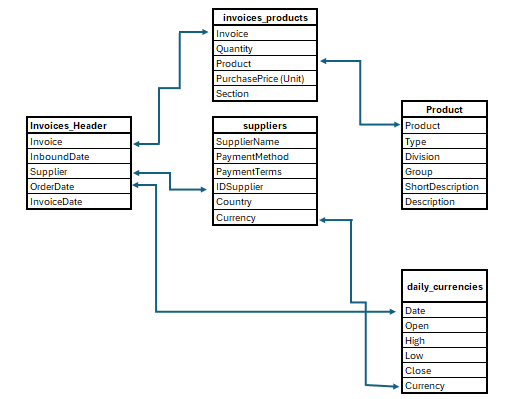

## **DESARROLLO**

##**1. Importar librerías**

In [ ]:
import os
import pandas as pd
import gc

##**2. Cargar las bases y mostrar datos**

In [ ]:
# Cargar los datos de invoices_header= invoices_header.
invoices_header= pd.read_csv("/content/sample_data/invoices_header.csv",sep=";",encoding='latin-1')
invoices_header

,Invoice,InboundDate,Supplier,OrderDate,InvoiceDate
0,FFCC141196,25/05/2014,PROV1650,10/05/2014,29/05/2014
1,FFCC141197,20/05/2014,PROV40000235,13/04/2014,23/05/2014
2,FFCC141198,12/05/2014,PROV1647,27/04/2014,15/05/2014
3,FFCC141199,19/05/2014,PROV40001000,24/03/2014,22/05/2014
4,FFCC141200,24/05/2014,PROV40000850,11/05/2014,27/05/2014
...,...,...,...,...,...
5173,FFCC212126,31/05/2021,PROV1649,26/04/2021,03/06/2021
5174,FFCC212127,07/06/2021,PROV2381,31/05/2021,10/06/2021
5175,FFCC212137,31/05/2021,PROV1129,04/04/2021,03/06/2021
5176,FFCC212138,01/05/2021,PROV1875,27/03/2021,04/05/2021


In [ ]:
# Cargar los datos de invoices_products= invoices_products.
invoices_products= pd.read_csv("/content/sample_data/invoices_products.csv",sep=";",encoding='latin-1')
invoices_products

,Invoice,Quantity,Product,PurchasePrice (Unit),Section
0,FFCC141196,1031,MP04245,0.4,Seccion A
1,FFCC141197,1931,MP04227,168.0,Seccion D
2,FFCC141198,360,MP02868,115.0,Seccion D
3,FFCC141198,240,MP02869,121.0,Seccion E
4,FFCC141199,18138,MP02700,0.1,Seccion E
...,...,...,...,...,...
39818,FFCC212138,2376,SE3174,0.0,Seccion D
39819,FFCC212138,6245,SE31101,0.1,Seccion F
39820,FFCC212138,819,SE3144,0.0,Seccion E
39821,FFCC212138,1291,SE31293,0.1,Seccion E


In [ ]:
# Cargar los datos de suppliers= suppliers.
suppliers= pd.read_csv("/content/sample_data/suppliers.csv",sep=";",encoding='latin-1')
suppliers

,SupplierName,PaymentMethod,PaymentTerms,IDSupplier,Country,Currency
0,Proveedor 3,RECIBO,1X30,PROV41000270,ES,EUR
1,Proveedor 4,RECIBO,1X60,PROV1344,ES,EUR
2,Proveedor 12,RECIBO,1X85,PROV40000010,ES,EUR
3,Proveedor 13,RECIBO,1X60,PROV40000187,ES,EUR
4,Proveedor 14,RECIBO,1X60,PROV40000200,ES,EUR
...,...,...,...,...,...,...
1219,Proveedor 1177,RECIBO,1X30,PROV2355,ES,EUR
1220,Proveedor 1188,RECIBO,1X60,PROV2366,ES,EUR
1221,Proveedor 1192,RECIBO,1X30,PROV2370,ES,EUR
1222,Proveedor 1195,VISA,ADELANTADO,PROV2373,ES,EUR


In [ ]:
# Cargar los datos de daily_currencies= daily_currencies.
daily_currencies= pd.read_csv("/content/sample_data/daily_currencies.csv",sep=";",encoding='latin-1')
daily_currencies

,Date,Open,High,Low,Close,Currency
0,28/03/2022,10.984,10.100,10.944,10.987,USD
1,25/03/2022,10.998,11.039,10.098,10.981,USD
2,24/03/2022,11.004,11.015,10.097,10.997,USD
3,23/03/2022,11.029,11.044,10.964,11.005,USD
4,22/03/2022,11.018,11.046,10.096,10.103,USD
...,...,...,...,...,...,...
2144,07/01/2014,13.628,13.628,13.617,13.617,USD
2145,06/01/2014,10.359,13.628,10.359,13.628,USD
2146,03/01/2014,13.673,13.673,10.359,10.359,USD
2147,02/01/2014,13.752,13.752,13.673,13.673,USD


In [ ]:
# === Cargar solo las columnas necesarias ===
invoices_header = pd.read_csv(
    "/content/sample_data/invoices_header.csv", sep=";", encoding="latin-1",
    usecols=["Invoice", "InboundDate", "Supplier", "OrderDate", "InvoiceDate"]
)

In [ ]:
invoices_products = pd.read_csv(
    "/content/sample_data/invoices_products.csv", sep=";", encoding="latin-1",
    usecols=["Invoice", "Quantity", "Product", "PurchasePrice (Unit)", "Section"]
)

In [ ]:
suppliers = pd.read_csv(
    "/content/sample_data/suppliers.csv", sep=";", encoding="latin-1",
    usecols=["IDSupplier", "Country", "Currency"]
)

In [ ]:
daily_currencies = pd.read_csv(
    "/content/sample_data/daily_currencies.csv",  # ruta completa al archivo
    sep=";",
    encoding="latin-1",
    usecols=["Date", "High", "Low", "Currency"]  # solo estas columnas
)

#**3. Limpieza de datos**

In [ ]:
# === Limpieza básica con debug ===
def clean_dataframe(df, name="DataFrame"):
    print(f"\n🔹 Limpieza de {name} - antes: {df.shape[0]} filas, {df.shape[1]} columnas")

    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].str.strip()

    for col in ["InboundDate", "OrderDate", "InvoiceDate", "Date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

    print(f"✔ {name} - después de limpieza: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(f"Columnas: {list(df.columns)}")
    print(df.head(3))  # muestra rápida
    return df
# Aplicar limpieza
invoices_header   = clean_dataframe(invoices_header, "invoices_header")
invoices_products = clean_dataframe(invoices_products, "invoices_products")
suppliers         = clean_dataframe(suppliers, "suppliers")
daily_currencies  = clean_dataframe(daily_currencies, "daily_currencies")



🔹 Limpieza de invoices_header - antes: 5178 filas, 5 columnas
✔ invoices_header - después de limpieza: 5178 filas, 5 columnas
Columnas: ['Invoice', 'InboundDate', 'Supplier', 'OrderDate', 'InvoiceDate']
      Invoice InboundDate      Supplier  OrderDate InvoiceDate
0  FFCC141196  2014-05-25      PROV1650 2014-05-10  2014-05-29
1  FFCC141197  2014-05-20  PROV40000235 2014-04-13  2014-05-23
2  FFCC141198  2014-05-12      PROV1647 2014-04-27  2014-05-15

🔹 Limpieza de invoices_products - antes: 39823 filas, 5 columnas
✔ invoices_products - después de limpieza: 39823 filas, 5 columnas
Columnas: ['Invoice', 'Quantity', 'Product', 'PurchasePrice (Unit)', 'Section']
      Invoice  Quantity  Product  PurchasePrice (Unit)    Section
0  FFCC141196      1031  MP04245                   0.4  Seccion A
1  FFCC141197      1931  MP04227                 168.0  Seccion D
2  FFCC141198       360  MP02868                 115.0  Seccion D

🔹 Limpieza de suppliers - antes: 1224 filas, 3 columnas
✔ supplier

## **4. Verificar calidad de datos**

In [ ]:
# === Completar calendario de divisas ===
fecha_min = invoices_header["OrderDate"].min()
fecha_max = invoices_header["OrderDate"].max()
print(f"\n📅 Rango de fechas detectado en invoices_header: {fecha_min} → {fecha_max}")

rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq="D")
daily_currencies = (
    daily_currencies.set_index("Date")
    .reindex(rango_fechas)
    .rename_axis("Date")
    .reset_index()
    .ffill()
)
print(f"✔ daily_currencies después de expandir calendario: {daily_currencies.shape}")
print(daily_currencies.head(3))


📅 Rango de fechas detectado en invoices_header: 2014-03-13 00:00:00 → 2021-05-31 00:00:00
✔ daily_currencies después de expandir calendario: (2637, 4)
        Date    High     Low Currency
0 2014-03-13  13.904  13.869      USD
1 2014-03-14  13.913  13.869      USD
2 2014-03-15  13.913  13.869      USD


## **5. Join optimizado**

In [ ]:
# === Joins optimizados (solo columnas necesarias) ===
# Paso 1: invoices_header + invoices_products
df1 = pd.merge(
    invoices_header,
    invoices_products,
    on="Invoice",
    how="left"
)
print(f"\n🔗 Paso 1 - header + products: {df1.shape}")
print(df1.head(3))
gc.collect()

# Paso 2: añadir suppliers (renombramos Currency para evitar conflicto)
suppliers = suppliers.rename(columns={"Currency": "SupplierCurrency"})
df2 = pd.merge(
    df1,
    suppliers,
    left_on="Supplier",
    right_on="IDSupplier",
    how="left"
)
print(f"\n🔗 Paso 2 - + suppliers: {df2.shape}")
print(df2.head(3))
del df1; gc.collect()

# Paso 3: añadir daily_currencies por OrderDate
df3 = pd.merge(
    df2,
    daily_currencies.rename(columns={
        "High": "High_OrderDate",
        "Low": "Low_OrderDate",
        "Currency": "Currency_OrderDate"
    }),
    left_on="OrderDate",
    right_on="Date",
    how="left"
)
print(f"\n🔗 Paso 3 - + daily_currencies (por OrderDate): {df3.shape}")
print(df3.head(3))
del df2; gc.collect()

# Paso 4: merge with daily_currencies by Date + Supplier Currency
daily_currencies_2 = daily_currencies.rename(columns={
    "Currency": "Currency_supplier",
    "High": "High_SupplierCurrency",
    "Low": "Low_SupplierCurrency",
    "tc_promedio_diario": "tc_promedio_diario_supplier"
})

df_final = pd.merge(
    df3,
    daily_currencies_2,
    left_on=["OrderDate", "SupplierCurrency"],
    right_on=["Date", "Currency_supplier"],
    how="left",
    suffixes=("", "_supplier_currency")
)

print(f"\n🔗 Paso 4 - + daily_currencies (por SupplierCurrency): {df_final.shape}")
print(df_final.head(5))


# === Resultado final ===
print("\n✅ Merge finalizado")
print(f"👉 Filas: {len(df_final)} | Columnas: {len(df_final.columns)}")
print(f"Columnas finales: {list(df_final.columns)}")
print(df_final.sample(5))


🔗 Paso 1 - header + products: (39823, 11)
      Invoice InboundDate      Supplier  OrderDate InvoiceDate  LeadTimeReal  \
0  FFCC141196  2014-05-25      PROV1650 2014-05-10  2014-05-29            15   
1  FFCC141197  2014-05-20  PROV40000235 2014-04-13  2014-05-23            37   
2  FFCC141198  2014-05-12      PROV1647 2014-04-27  2014-05-15            15   

   Quantity  Product  PurchasePrice (Unit)    Section  ImporteXCompras  
0      1031  MP04245                   0.4  Seccion A            412.4  
1      1931  MP04227                 168.0  Seccion D         324408.0  
2       360  MP02868                 115.0  Seccion D          41400.0  

🔗 Paso 2 - + suppliers: (39823, 14)
      Invoice InboundDate      Supplier  OrderDate InvoiceDate  LeadTimeReal  \
0  FFCC141196  2014-05-25      PROV1650 2014-05-10  2014-05-29            15   
1  FFCC141197  2014-05-20  PROV40000235 2014-04-13  2014-05-23            37   
2  FFCC141198  2014-05-12      PROV1647 2014-04-27  2014-05-15     

## **6. Fichero CVS**

In [ ]:
# === Exportar df_final a CSV ===
output_path = r"C:\Users\Teresa\OneDrive\Escritorio\Data_Ing\df_final.csv"

df_final.to_csv(output_path, sep=";", index=False, encoding="utf-8-sig")

print(f"✅ Archivo exportado correctamente en: {output_path}")

✅ Archivo exportado correctamente en: C:\Users\Teresa\OneDrive\Escritorio\Data_Ing\df_final.csv


##**7. Cálculos**

### **Tipo de cambio promedio diario**

In [ ]:
# Tipo de cambio promedio diario
daily_currencies["tc_promedio_diario"] = (daily_currencies["Low"] + daily_currencies["High"]) / 2
print(daily_currencies["tc_promedio_diario"])

0       13.8865
1       13.8910
2       13.8910
3       13.8910
4       13.9175
         ...   
2632    12.1950
2633    12.1695
2634    12.1695
2635    12.1695
2636    12.2080
Name: tc_promedio_diario, Length: 2637, dtype: float64


## **Tiempo de reparto real**

In [ ]:
# leadTimeReal
LeadTimeReal=1
LeadTimeReal

1

In [ ]:
# 3.1 Calcular Lead Time Real
invoices_header['LeadTimeReal'] = (invoices_header['InboundDate'] - invoices_header['OrderDate']).dt.days
invoices_header

,Invoice,InboundDate,Supplier,OrderDate,InvoiceDate,LeadTimeReal
0,FFCC141196,2014-05-25,PROV1650,2014-05-10,2014-05-29,15
1,FFCC141197,2014-05-20,PROV40000235,2014-04-13,2014-05-23,37
2,FFCC141198,2014-05-12,PROV1647,2014-04-27,2014-05-15,15
3,FFCC141199,2014-05-19,PROV40001000,2014-03-24,2014-05-22,56
4,FFCC141200,2014-05-24,PROV40000850,2014-05-11,2014-05-27,13
...,...,...,...,...,...,...
5173,FFCC212126,2021-05-31,PROV1649,2021-04-26,2021-06-03,35
5174,FFCC212127,2021-06-07,PROV2381,2021-05-31,2021-06-10,7
5175,FFCC212137,2021-05-31,PROV1129,2021-04-04,2021-06-03,57
5176,FFCC212138,2021-05-01,PROV1875,2021-03-27,2021-05-04,35


**Importe por compras**

In [ ]:
# Importe por compras q x p
# Generar medida ImporteXCompras
invoices_products['ImporteXCompras'] = (invoices_products['Quantity'] * invoices_products['PurchasePrice (Unit)'])
display(invoices_products.head())

,Invoice,Quantity,Product,PurchasePrice (Unit),Section,ImporteXCompras
0,FFCC141196,1031,MP04245,0.4,Seccion A,412.4
1,FFCC141197,1931,MP04227,168.0,Seccion D,324408.0
2,FFCC141198,360,MP02868,115.0,Seccion D,41400.0
3,FFCC141198,240,MP02869,121.0,Seccion E,29040.0
4,FFCC141199,18138,MP02700,0.1,Seccion E,1813.8


**Importe de compras en euros**

In [ ]:
import numpy as np

df_final['ImporteXCompras_euros'] = np.where(
    df_final['SupplierCurrency'] == "EUR",
    df_final['ImporteXCompras'],
    df_final['ImporteXCompras'] * df_final['tc_promedio_diario']
)
print(df_final[['ImporteXCompras', 'SupplierCurrency', 'tc_promedio_diario', 'ImporteXCompras_euros']].head())

   ImporteXCompras SupplierCurrency  tc_promedio_diario  ImporteXCompras_euros
0            412.4              EUR             13.8000                  412.4
1         324408.0              EUR             13.8865               324408.0
2          41400.0              EUR             13.8335                41400.0
3          29040.0              EUR             13.8335                29040.0
4           1813.8              EUR             12.0890                 1813.8


## **8. Indicador de monto por compras**

In [ ]:
import pandas as pd

# Agrupación por OrderDate y Section, sumando los importes en euros
df_agrupado = (
    df_final
    .groupby(['OrderDate', 'Section'], as_index=False)['ImporteXCompras_euros']
    .sum()
)

print(df_agrupado.head(20))

    OrderDate    Section  ImporteXCompras_euros
0  2014-03-13  Seccion D           3.118000e+02
1  2014-03-13  Seccion E           6.000000e+02
2  2014-03-24  Seccion E           1.813800e+03
3  2014-04-03  Seccion E           3.959550e+05
4  2014-04-04  Seccion B           0.000000e+00
5  2014-04-05  Seccion C           8.503290e+03
6  2014-04-05  Seccion D           0.000000e+00
7  2014-04-05  Seccion E           0.000000e+00
8  2014-04-05  Seccion F           1.246400e+03
9  2014-04-06  Seccion A           6.591600e+03
10 2014-04-06  Seccion B           2.095920e+04
11 2014-04-06  Seccion C           1.531535e+07
12 2014-04-06  Seccion D           2.515120e+04
13 2014-04-06  Seccion E           7.153200e+03
14 2014-04-06  Seccion F           3.187200e+03
15 2014-04-08  Seccion B           0.000000e+00
16 2014-04-08  Seccion E           0.000000e+00
17 2014-04-09  Seccion D           8.146868e+04
18 2014-04-10  Seccion A           9.353196e+05
19 2014-04-10  Seccion B           3.665

## **9. Análisis de Proveedores**

### Ranking de Proveedores por Importe Total Comprado

In [ ]:
# Calculate the total purchase amount per supplier
supplier_ranking_by_amount = df_final.groupby('Supplier')['ImporteXCompras_euros'].sum().reset_index()

# Sort the suppliers by total purchase amount in descending order
supplier_ranking_by_amount = supplier_ranking_by_amount.sort_values(by='ImporteXCompras_euros', ascending=False)

# Display the ranking
print("Ranking de Proveedores por Importe Total Comprado:")
display(supplier_ranking_by_amount.head())

Ranking de Proveedores por Importe Total Comprado:


,Supplier,ImporteXCompras_euros
47,PROV1585,7.766775e+09
35,PROV1475,6.650661e+09
24,PROV1398,1.285627e+09
113,PROV1976,1.209842e+09
5,PROV1061,6.722473e+08


## **Ranking de Proveedores por Número de Productos Distintos Comprados**

In [ ]:
# Calculate the number of distinct products bought from each supplier
supplier_ranking_by_products = df_final.groupby('Supplier')['Product'].nunique().reset_index()

# Sort the suppliers by the number of distinct products in descending order
supplier_ranking_by_products = supplier_ranking_by_products.sort_values(by='Product', ascending=False)

# Rename the column for clarity
supplier_ranking_by_products.rename(columns={'Product': 'DistinctProductCount'}, inplace=True)

# Display the ranking
print("\nRanking de Proveedores por Número de Productos Distintos Comprados:")
display(supplier_ranking_by_products.head())


Ranking de Proveedores por Número de Productos Distintos Comprados:


,Supplier,DistinctProductCount
47,PROV1585,702
5,PROV1061,657
113,PROV1976,591
88,PROV1875,506
38,PROV1485,415


## **Análisis de Lead Time Real vs. Teórico**

In [ ]:
# Calculate Lead Time Real (already done in df_final, but let's ensure it's correct)
# df_final['LeadTimeReal'] = (df_final['InboundDate'] - df_final['OrderDate']).dt.days

# Determine Lead Time Teórico based on Country
def calculate_theoretical_lead_time(Country):
    if Country == 'ES':
        return 10
    elif Country in ['FR', 'IE', 'CH', 'DE']: # Assuming these are the European countries other than Spain
        return 20
    else:
        return 45

df_final['LeadTimeTeorico'] = df_final['Country'].apply(calculate_theoretical_lead_time)

# Calculate the difference between Real and Theoretical Lead Time
df_final['LeadTimeDifference'] = df_final['LeadTimeReal'] - df_final['LeadTimeTeorico']

# Analyze Lead Time by Product-Supplier combination (Annual Average)
# Extract Year from OrderDate for annual aggregation
df_final['OrderYear'] = df_final['OrderDate'].dt.year

# Group by Product, Supplier, and Year, and calculate the mean Lead Times
lead_time_analysis = df_final.groupby(['Product', 'Supplier', 'OrderYear'])[['LeadTimeReal', 'LeadTimeTeorico', 'LeadTimeDifference']].mean().reset_index()

# Display the lead time analysis
print("\nAnálisis de Lead Time Promedio Anual por Producto-Proveedor:")
display(lead_time_analysis.head())


Análisis de Lead Time Promedio Anual por Producto-Proveedor:


,Product,Supplier,OrderYear,LeadTimeReal,LeadTimeTeorico,LeadTimeDifference
0,DE0001,PROV2197,2019,23.0,20.0,3.0
1,DE0002,PROV2197,2019,23.0,20.0,3.0
2,DE0003,PROV2197,2019,23.0,20.0,3.0
3,DE0004,PROV2197,2019,23.0,20.0,3.0
4,DE0005,PROV2197,2019,23.0,20.0,3.0
